# German Electricity Price Forecast - hourly 

## EDA - Price vs Time
* fetch data from SMARD API and save to SQLite database automatically with ETL pipeline
    - Scrape prices and other data from SMARD
    - Ingest into SQLite DB
* Load data and EDA

In [1]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd

from etl_price import *
#from fetch_price_data import *
from train_predict_model import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})


## Prepare raw data

* update database 
    - check data status
    - fetch data from SMARD
    - ingest into database
* tables 
    - data_quality_log:
        - ['id', 'run_id', 'series_id', 'check_name', 'result', 'details', 'checked_at']
    - energy_demand:
        - ['time', 'energy_demand_mwh', 'smard_forecast_mwh', 'data_source', 'year', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'holiday_ratio', 'is_workday', 'is_bridge_day', 'holiday_weight', 'is_pandemic_time', 'energy_demand_lag_24h', 'energy_demand_lag_168h', 'energy_demand_rolling_mean_24h', 'energy_demand_rolling_mean_168h']
    - ingestion_runs:
        - ['run_id', 'start_ts', 'end_ts', 'status', 'source', 'rows_loaded', 'error_text']
    - series_catalog:
        - ['series_id', 'source', 'filter_id', 'region', 'resolution', 'unit', 'active', 'description', 'created_at', 'updated_at']
    - timeseries_values:
        - ['time', 'series_id', 'value', 'data_source', 'fetched_at', 'version']
    - weather:
        - ['time', 'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'apparent_temperature_lag_24h', 'apparent_temperature_rolling_mean_24h', 'shortwave_radiation_0m_lag_24h', 'shortwave_radiation_0m_rolling_mean_24h', 'heating_degree', 'cooling_degree']
* series_id:
    - ['price_de_lu_eur_mwh', 'gen_wind_onshore_mwh', 'gen_wind_offshore_mwh', 'gen_pv_mwh', 'gen_other_conventional_mwh']

In [ ]:
import sqlite3

conn = sqlite3.connect("../db/energy_demand.db")
cur = conn.cursor()

# Rename the column "time_utc" to "time" in the "timeseries_values" table
cur.execute("ALTER TABLE timeseries_values RENAME COLUMN time_utc TO time;")
conn.commit()
conn.close()

In [3]:
# update database with new data
import sqlalchemy as sa
from etl_price import update_database

#update_database(start_date='2019-01-01', end_date='2026-05-27')

engine = sa.create_engine('sqlite:///../db/energy_demand.db')
inpector = sa.inspect(engine)
table_names = inpector.get_table_names()
for table in table_names:
    print(f"Columns in {table}:\n {[col['name'] for col in inpector.get_columns(table)]}")

Columns in data_quality_log:
 ['id', 'run_id', 'series_id', 'check_name', 'result', 'details', 'checked_at']
Columns in energy_demand:
 ['time', 'energy_demand_mwh', 'smard_forecast_mwh', 'data_source', 'year', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'holiday_ratio', 'is_workday', 'is_bridge_day', 'holiday_weight', 'is_pandemic_time', 'energy_demand_lag_24h', 'energy_demand_lag_168h', 'energy_demand_rolling_mean_24h', 'energy_demand_rolling_mean_168h']
Columns in ingestion_runs:
 ['run_id', 'start_ts', 'end_ts', 'status', 'source', 'rows_loaded', 'error_text']
Columns in series_catalog:
 ['series_id', 'source', 'filter_id', 'region', 'resolution', 'unit', 'active', 'description', 'created_at', 'updated_at']
Columns in timeseries_values:
 ['time', 'series_id', 'value', 'data_source', 'fetched_at', 'version']
Columns in weather:
 ['time', 'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'apparent_temperature_lag_24h', 'apparent_temperat

## Check the structure, data types and values

* Load data from db
* check info, describe

In [5]:
import sqlalchemy as sa
import pandas as pd

engine = sa.create_engine('sqlite:///../db/energy_demand.db')
query_price_gen = "SELECT * FROM timeseries_values"
query_series = "SELECT * FROM series_catalog"
query_demand = "SELECT * FROM energy_demand"
df_price_gen = pd.read_sql(query_price_gen, engine)
df_series = pd.read_sql(query_series, engine)
df_demand = pd.read_sql(query_demand, engine)

df_price_gen = df_price_gen.pivot(index='time', columns='series_id', values='value').reset_index()
df_price_gen['time'] = pd.to_datetime(df_price_gen['time'], utc=True)
df_demand['time'] = pd.to_datetime(df_demand['time'], utc=True)

df_price_gen = df_price_gen.dropna()
df_demand = df_demand.dropna()

print(df_price_gen['time'].dtype)
print(df_demand['time'].dtype)

print(df_price_gen['time'].isna().sum())
print(df_demand['time'].isna().sum())

df_demand_price = pd.merge(df_demand, df_price_gen, on='time', how='inner')
df_demand_price = df_demand_price.drop('data_source', axis=1)
display(df_demand_price.head())

# Pivot the DataFrame to have 'time' as the index and 'series_id' as columns


datetime64[us, UTC]
datetime64[us, UTC]
0
0


,time,energy_demand_mwh,smard_forecast_mwh,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,...,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
0,2019-01-08 00:00:00+00:00,52754.4700,49815.00,2019,1,1,1,0,0,0.0,...,0.0,3552.00,33866.00,20.91,98.415336,0.0,0.0,0.0,277.667750,70.300514
1,2019-01-08 01:00:00+00:00,51889.2625,49241.75,2019,2,1,1,0,0,0.0,...,0.0,3463.75,33839.50,7.78,97.908920,0.0,0.0,0.0,279.993784,77.633547
2,2019-01-08 02:00:00+00:00,52475.5475,49512.25,2019,3,1,1,0,0,0.0,...,0.0,3473.25,34115.75,14.33,96.830635,0.0,0.0,0.0,282.526055,78.192938
3,2019-01-08 03:00:00+00:00,54096.5250,50572.75,2019,4,1,1,0,0,0.0,...,0.0,3129.75,34217.25,18.56,81.153676,0.0,0.0,0.0,282.563489,77.277288
4,2019-01-08 04:00:00+00:00,57487.6050,53273.00,2019,5,1,1,0,0,0.0,...,0.0,2986.00,34361.50,18.57,87.807787,0.0,0.0,0.0,285.374187,79.763246


In [46]:
display(df_series['series_id'].unique())

display(df_price_gen.info())
display(df_price_gen.describe())
print(f'time range: {df_price_gen["time"].min()} to {df_price_gen["time"].max()}')
display(df_price_gen.head())



<ArrowStringArray>
[             'price_de_lu_eur_mwh',             'gen_wind_onshore_mwh',
            'gen_wind_offshore_mwh',                       'gen_pv_mwh',
       'gen_other_conventional_mwh',   'pv_weather_shortwave_radiation',
      'pv_weather_direct_radiation',     'pv_weather_diffuse_radiation',
           'pv_weather_cloud_cover',     'wind_weather_wind_speed_100m',
 'wind_weather_wind_direction_100m',        'forecast_wind_onshore_mwh',
       'forecast_wind_offshore_mwh',                  'forecast_pv_mwh']
Length: 14, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 65207 entries, 0 to 65206
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   time                              65207 non-null  datetime64[us, UTC]
 1   forecast_pv_mwh                   65207 non-null  float64            
 2   forecast_wind_offshore_mwh        65207 non-null  float64            
 3   forecast_wind_onshore_mwh         65207 non-null  float64            
 4   gen_other_conventional_mwh        65194 non-null  float64            
 5   gen_pv_mwh                        65194 non-null  float64            
 6   gen_wind_offshore_mwh             65194 non-null  float64            
 7   gen_wind_onshore_mwh              65193 non-null  float64            
 8   price_de_lu_eur_mwh               65207 non-null  float64            
 9   pv_weather_cloud_cover            65183 non-null  float64            
 1

None

series_id,forecast_pv_mwh,forecast_wind_offshore_mwh,forecast_wind_onshore_mwh,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
count,65207.000000,65207.000000,65207.000000,65194.000000,65194.000000,65194.000000,65193.000000,65207.000000,65183.000000,65183.000000,65183.000000,65183.000000,65183.000000,65183.000000
mean,6401.612199,2886.901136,11902.667537,1593.570525,6394.301882,2899.231262,11970.590717,94.858264,65.927355,54.148315,81.595521,135.743836,204.538359,30.940152
std,9959.856041,1889.630613,9378.785441,266.834499,10027.795705,1967.934367,9464.746238,92.002115,27.858708,72.047117,140.883062,200.418395,75.688952,12.987583
min,0.000000,13.000000,161.250000,530.750000,0.000000,0.000000,46.500000,-500.000000,0.000000,0.000000,0.000000,0.000000,8.285717,3.491786
25%,0.000000,1134.750000,4577.375000,1414.750000,3.000000,1108.500000,4526.500000,38.250000,46.358936,0.000000,0.000000,0.000000,145.271645,21.247965
50%,244.000000,2720.750000,9164.250000,1576.750000,194.000000,2684.875000,9263.250000,77.000000,71.729509,5.770677,0.967004,7.292187,218.179864,29.179950
75%,10089.125000,4572.875000,16903.750000,1788.557500,9979.562500,4585.385000,17180.750000,116.580000,90.192462,98.312681,107.741658,221.608000,263.247161,38.636991
max,56410.320000,7344.190000,46758.440000,2669.500000,56071.650000,8448.340000,48499.500000,936.280000,100.000000,370.848847,766.031637,886.747525,355.010877,104.787703


time range: 2018-12-31 23:00:00+00:00 to 2026-06-09 21:00:00+00:00


series_id,time,forecast_pv_mwh,forecast_wind_offshore_mwh,forecast_wind_onshore_mwh,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh,pv_weather_cloud_cover,pv_weather_diffuse_radiation,pv_weather_direct_radiation,pv_weather_shortwave_radiation,wind_weather_wind_direction_100m,wind_weather_wind_speed_100m
0,2018-12-31 23:00:00+00:00,0.0,5069.00,18879.75,1724.25,0.0,3134.00,20314.25,28.32,95.228754,0.0,0.0,0.0,257.697773,53.486212
1,2019-01-01 00:00:00+00:00,0.0,5042.25,20626.50,1682.25,0.0,2868.25,22297.25,10.07,93.784571,0.0,0.0,0.0,255.540277,58.021481
2,2019-01-01 01:00:00+00:00,0.0,5028.50,22355.50,1625.25,0.0,2460.25,23168.50,-4.08,99.448610,0.0,0.0,0.0,259.660683,59.465160
3,2019-01-01 02:00:00+00:00,0.0,4977.75,24032.50,1615.25,0.0,2696.50,24471.75,-9.91,100.000000,0.0,0.0,0.0,264.739757,60.351696
4,2019-01-01 03:00:00+00:00,0.0,4907.25,25452.00,1621.50,0.0,2578.00,26320.50,-7.41,98.505048,0.0,0.0,0.0,269.234658,61.293313


## Plot price and generation value distribution in histogram

* seemingly outliers are present in prices. 
* The other conventional generation has similiar distribution as price, can be used as reference for outlier identification/regression with RANSAC
* The negative prices concentrate in May since 2023. A time feature candidate.
* RANSAC with residual_thredshold=700 finds outliers concentrate on two time slots too

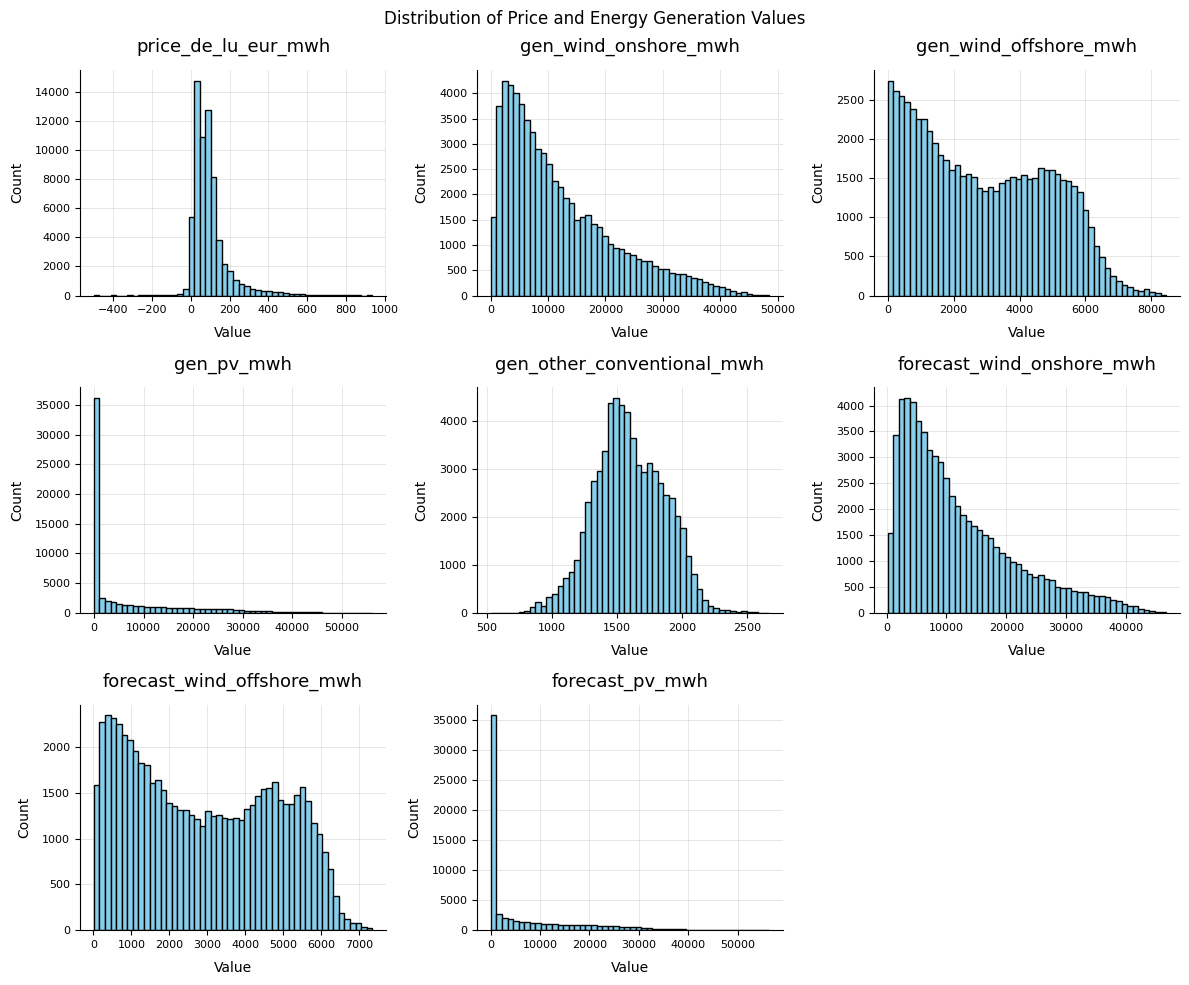

In [47]:
# Plot histogram of the price and energy generation values
from fetch_price_data import normalize_time_column
#df_price_min = normalize_time_column(df_price, col="time_utc", freq="min")  # für Minuten
#df_hour = normalize_time_column(df_price_gen, col="time", freq="h")    # für Stunden

cols_price_gen = ['price_de_lu_eur_mwh',  
                  'gen_wind_onshore_mwh', 'gen_wind_offshore_mwh', 
                  'gen_pv_mwh', 'gen_other_conventional_mwh',
                  'forecast_wind_onshore_mwh', 'forecast_wind_offshore_mwh', 'forecast_pv_mwh']

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(cols_price_gen):
    ax = axes[i]
    df_subset = df_price_gen[col]
    ax.hist(df_subset, bins=50, color='skyblue', edgecolor='black')
    ax.set_title(f'{col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

axes[8].axis('off') 
fig.suptitle('Distribution of Price and Energy Generation Values')  # Hide the unused subplot
plt.tight_layout()
plt.show()


## 

## Price and generation value on time series

* Solar generation and price are negative correlated
* Surprisingly wind onshore and offshore and price have seemingly timely shifted correlation

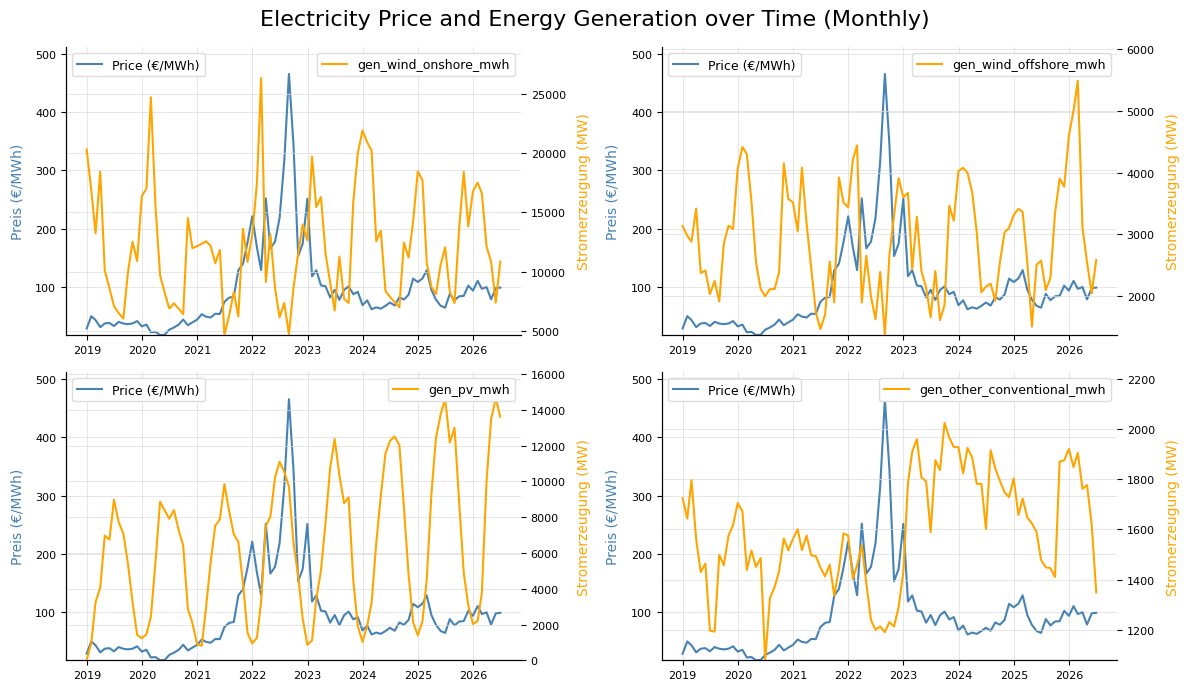

In [48]:
from fetch_price_data import normalize_time_column
# resample the data to monthly frequency by taking the mean value for each month    
df_monthly = df_price_gen.reset_index().resample('ME', on='time').mean(numeric_only=True)

df_monthly_price = df_monthly['price_de_lu_eur_mwh']

df_monthly_wind_onshore = df_monthly['gen_wind_onshore_mwh']
df_monthly_wind_offshore = df_monthly['gen_wind_offshore_mwh']
df_monthly_solar = df_monthly['gen_pv_mwh']
df_monthly_other = df_monthly['gen_other_conventional_mwh']

cols_gen = ['gen_wind_onshore_mwh', 'gen_wind_offshore_mwh', 'gen_pv_mwh', 'gen_other_conventional_mwh']

# plot the time series of the price and energy generation values each in one plot using twinx
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax = ax.flatten()
for i, col in enumerate(cols_gen):
    ax[i].plot(df_monthly_price.index, df_monthly_price, label='Price (€/MWh)', color='steelblue')
    ax_twinx = ax[i].twinx()
    ax_twinx.plot(df_monthly.index, df_monthly[col], color='orange', label=col)
    
    ax[i].set_ylabel('Preis (€/MWh)', color='steelblue')
    ax_twinx.set_ylabel('Stromerzeugung (MW)', color='orange')
    ax[i].legend(loc='upper left')
    ax_twinx.legend(loc='upper right')
    ax[i].set_ylim(df_monthly_price.min(), df_monthly_price.max() * 1.1)
    ax_twinx.set_ylim(df_monthly[col].min(), df_monthly[col].max() * 1.1)
plt.suptitle('Electricity Price and Energy Generation over Time (Monthly)', fontsize=16)
plt.tight_layout()
plt.show()


### Correlation in scatter plot
* confirms the impression of correlationship in the previous plots

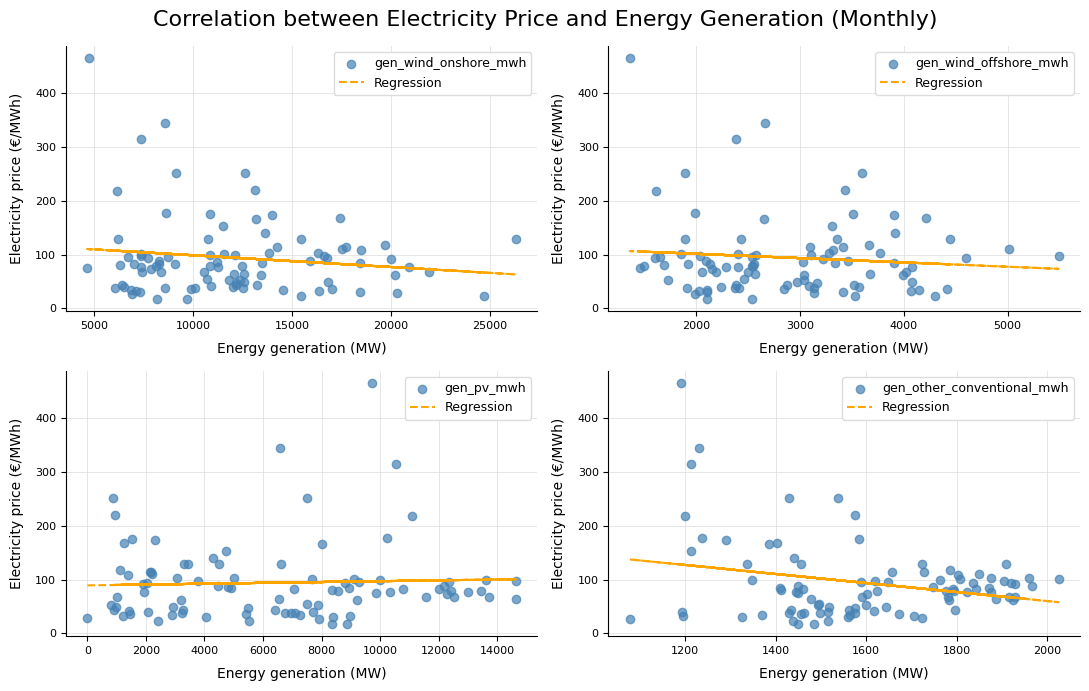

In [49]:
# plot correlation and regression between price and generation values using scatter plot
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax = ax.flatten()
for i, col in enumerate(cols_gen):
    ax[i].scatter(df_monthly[col], df_monthly['price_de_lu_eur_mwh'], label=col, color='steelblue', alpha=0.7)
    m, b = np.polyfit(df_monthly[col], df_monthly['price_de_lu_eur_mwh'], 1)
    ax[i].plot(df_monthly[col], m * df_monthly[col] + b, color='orange', linestyle='--', label='Regression')
    ax[i].set_xlabel('Energy generation (MW)')
    ax[i].set_ylabel('Electricity price (€/MWh)')
    ax[i].legend()
plt.suptitle('Correlation between Electricity Price and Energy Generation (Monthly)', fontsize=16)
plt.tight_layout()
plt.show()


## Quantitative correlationship
* Solar generation is significantly negatively correlated with price
* Wind onshore and offshore and conventional generation play a role too 

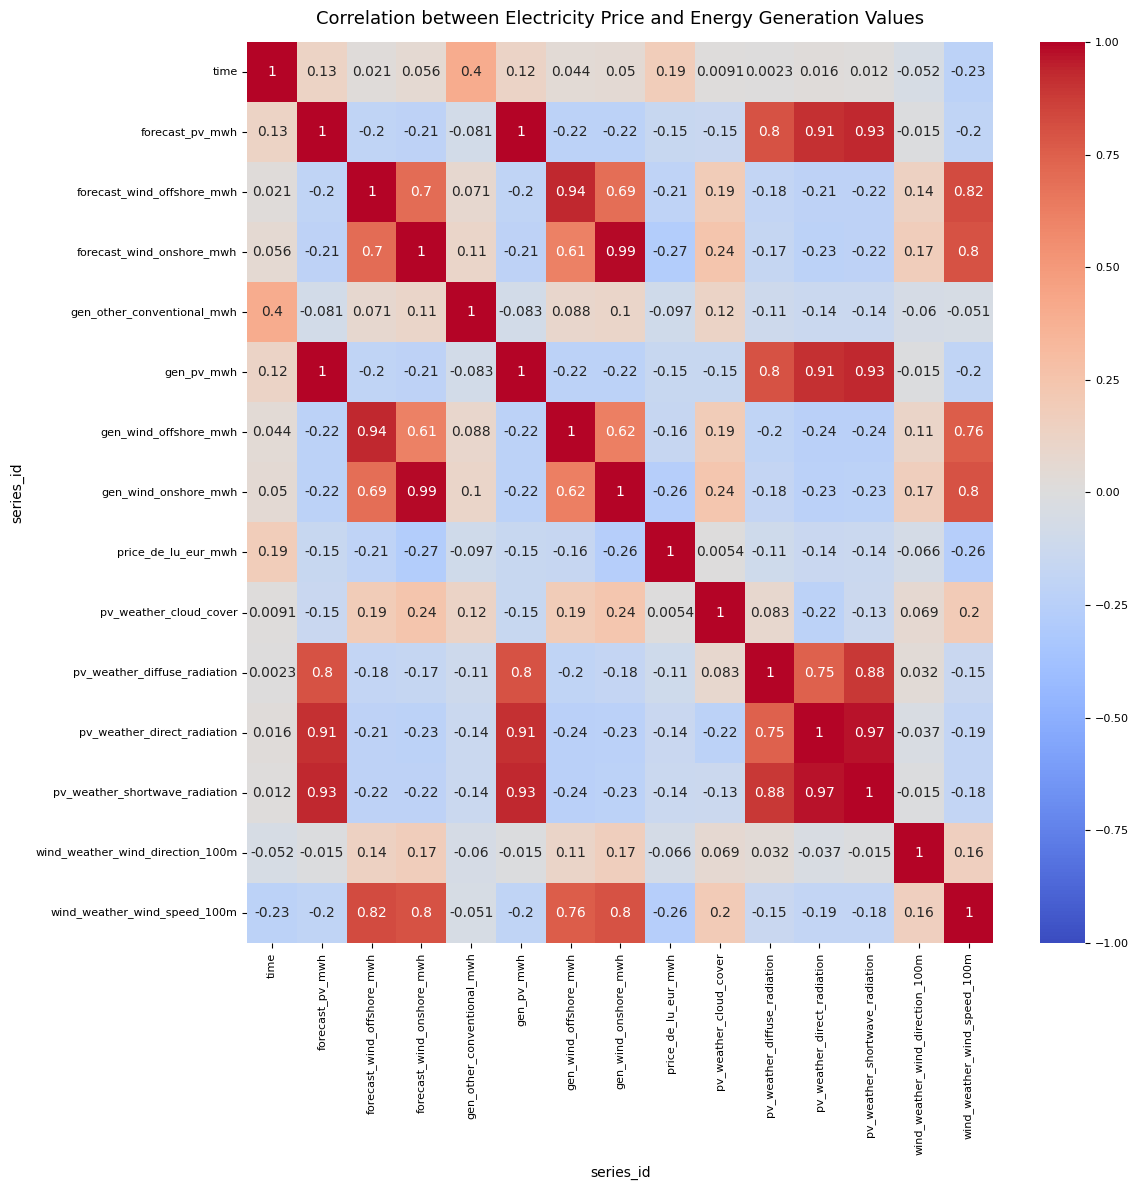

In [50]:
# plot correlation using heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# set plot size and title
plt.figure(figsize=(12, 12))
sns.heatmap(df_price_gen.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Electricity Price and Energy Generation Values')
plt.tight_layout()
plt.show()

## Outlier analysis

* Identify outliers
    - Price limit < -100 
        - Noon times in Apr, May (most) and Jul since 2023
    - RANSACRegressor. Try difference residual_threshold values emperically 
        - residual_threshold=700.0 
            - different times in Aug 2022 and Nov, Dec 2024
    - DBScan (eps=0.95)

* Handle outliers
    - Create time features: safe
    - Flag is_outlier: safe no information lost
    - Imputation: replacement nearest neighbour. Possibly distort data characters.
    - Remove: gaps in time series

* Conclusion
    - Regime A: energy crisis 2022
        - high price, usual consumption/demand
        - political/market factors
            - gas/oil supply crisis
            - Ukraine war 
            - North stream conflicts

    - Regime B: Solar over production/energy storage shortage
        - negative prices 
        - moderate load/demand
        - high renewable energy generation

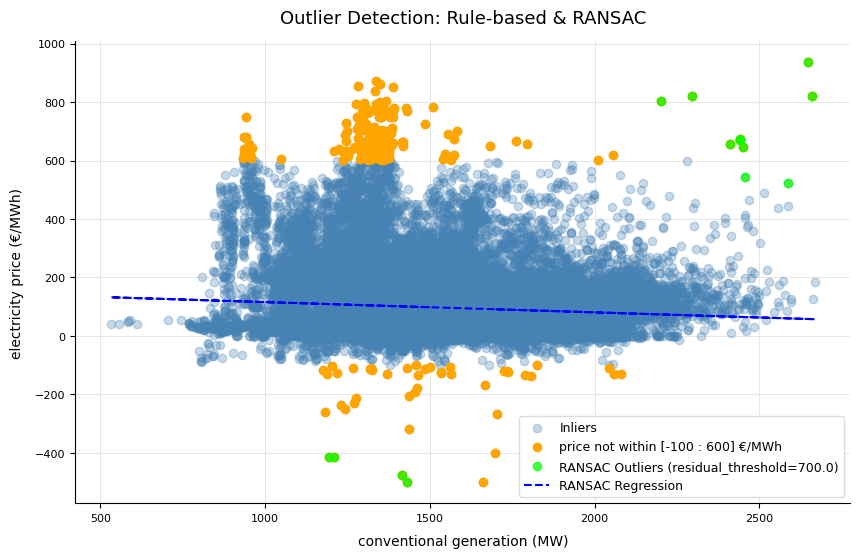

Rule-based outliers: 212 / 64696
RANSAC Inliers: 64682 / 64696 (without rule-based outliers)
RANSAC Outliers: 14 / 64696 (without rule-based outliers)


In [31]:
# Kombinierte AusreiÃŸer-Erkennung: Regelbasiert (Preis < -400) + RANSAC
from sklearn.linear_model import RANSACRegressor

# rule-based outlier detection: price < -400
price_upper_limit = 600
price_lower_limit = -100
outlier_mask_rule = (df_demand_price['price_de_lu_eur_mwh'] < price_lower_limit) | (df_demand_price['price_de_lu_eur_mwh'] > price_upper_limit)
inlier_mask_rule = ~outlier_mask_rule

# RANSAC outlier detection on the entire dataset (without excluding rule-based outliers)
ransac_threshold = 700.0
#X = df_demand_price.loc[inlier_mask_rule, 'gen_other_conventional_mwh'].values.reshape(-1, 1)
#y = df_demand_price.loc[inlier_mask_rule, 'price_de_lu_eur_mwh'].values
X = df_demand_price['gen_other_conventional_mwh'].values.reshape(-1, 1)
y = df_demand_price['price_de_lu_eur_mwh'].values
ransac = RANSACRegressor(residual_threshold=ransac_threshold, random_state=42)
ransac.fit(X, y)
inlier_mask_ransac = ransac.inlier_mask_
outlier_mask_ransac = ~inlier_mask_ransac

plt.figure(figsize=(10, 6))
# Inlier (blue)
plt.scatter(X, y, color='steelblue', label='Inliers', alpha=0.3)
# rule-based outliers (red)
plt.scatter(df_demand_price.loc[outlier_mask_rule, 'gen_other_conventional_mwh'],
            df_demand_price.loc[outlier_mask_rule, 'price_de_lu_eur_mwh'],
            color='orange', label=f'price not within [{price_lower_limit} : {price_upper_limit}] €/MWh')
# RANSAC-Outlier (yellow)
plt.scatter(X[outlier_mask_ransac], y[outlier_mask_ransac], color='lime', label=f'RANSAC Outliers (residual_threshold={ransac_threshold})', alpha=0.7)
# RANSAC-Regression line
plt.plot(X, ransac.predict(X), color='blue', linestyle='--', label='RANSAC Regression')
plt.xlabel('conventional generation (MW)')
plt.ylabel('electricity price (€/MWh)')
plt.title('Outlier Detection: Rule-based & RANSAC')
plt.legend()
plt.show()

print(f"Rule-based outliers: {outlier_mask_rule.sum()} / {len(df_demand_price)}")
print(f"RANSAC Inliers: {inlier_mask_ransac.sum()} / {len(X)} (without rule-based outliers)")
print(f"RANSAC Outliers: {outlier_mask_ransac.sum()} / {len(X)} (without rule-based outliers)")

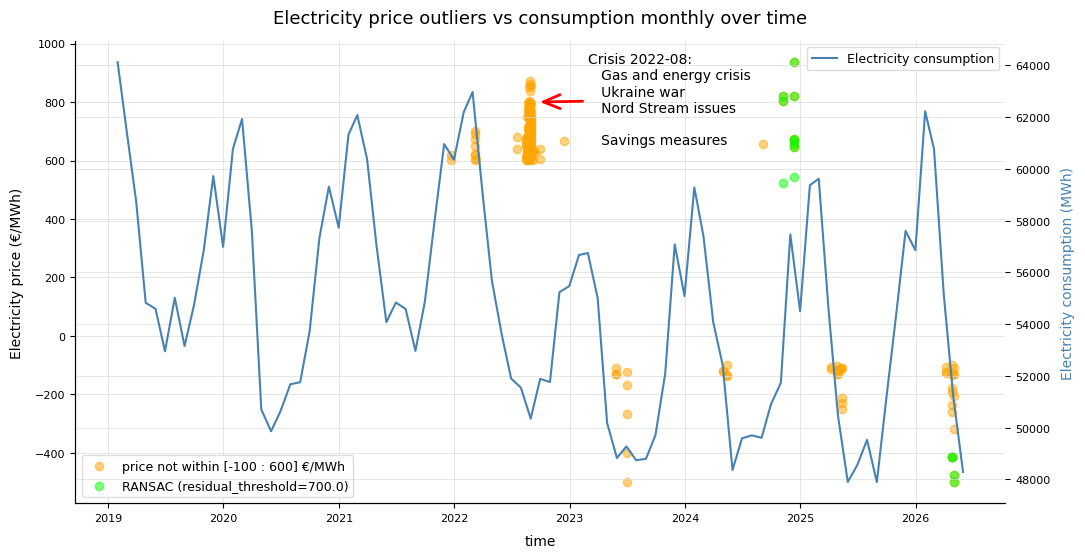

In [ ]:
# outliers timely distributed?
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor 

df_demand_price_monthly = df_demand_price.resample('ME', on='time').mean(numeric_only=True).reset_index()
df_renewable_gen_monthly = df_demand_price_monthly.copy()
df_renewable_gen_monthly['renewable_gen_mwh'] = df_demand_price_monthly['gen_wind_onshore_mwh'] + df_demand_price_monthly['gen_wind_offshore_mwh'] + df_demand_price_monthly['gen_pv_mwh']

# time index of RANSAC outliers (only based on the rule-based inliers!)
index_inlier = df_demand_price[inlier_mask_rule].index
index_ransac_outlier = df_demand_price[outlier_mask_ransac].index

fig, ax = plt.subplots(figsize=(12, 6))

# rule based outliers (on entire df_demand_price)
ax.scatter(df_demand_price.loc[outlier_mask_rule, 'time'], 
            df_demand_price.loc[outlier_mask_rule, 'price_de_lu_eur_mwh'], 
            label=f'price not within [{price_lower_limit} : {price_upper_limit}] €/MWh', color='orange', alpha=0.5)
# RANSAC outliers (on time index of rule-based inliers)
ransac_threshold = 700.0
ax.scatter(df_demand_price.loc[index_ransac_outlier, 'time'], 
            df_demand_price.loc[index_ransac_outlier, 'price_de_lu_eur_mwh'], 
            label=f'RANSAC (residual_threshold={ransac_threshold})', color='lime', alpha=0.5)
# Line plot of energy demand
ax_twinx = ax.twinx()
ax_twinx.plot(df_demand_price_monthly['time'], df_demand_price_monthly['energy_demand_mwh'], label='Electricity consumption', color='steelblue')

ax.set_ylabel('price (€/MWh)')
ax_twinx.set_ylabel('Energy generation (MW)', color='steelblue')
ax.set_xlabel('time')
ax.set_ylabel('Electricity price (€/MWh)')
ax.annotate('Crisis 2022-08:\n   Gas and energy crisis\n   Ukraine war\n   Nord Stream issues\n\n   Savings measures', 
            xy=(pd.Timestamp('2022-09-20'), 800), xytext=(pd.Timestamp('2023-03-01'), 970),
            arrowprops=dict(arrowstyle='->,head_length=1.2,head_width=0.5', facecolor="red", edgecolor='red', linewidth=2), 
            fontsize=10, color= 'black', ha='left', va='top')
ax.legend(loc='lower left')
ax_twinx.legend(loc='upper right')
ax_twinx.set_ylabel('Electricity consumption (MWh)')

plt.title('Electricity price outliers vs consumption monthly over time')
plt.legend()
plt.show()


## Conclusion - outliers

* High prices 
    - 2022.08: Energy crisis, Ukraine ware, North Stream issues
    - End of 2025: infrucstruture investment, higher price on stock market, end of energy price subvention  
* Negative prices 
    - Timely pattern: 
        - Weekend and holiday
        - Noon time in early summer
    - Posssible reasons:
        - Industrial and prive household consumption sink, while renewable energy generation increases
        - Limited storage capacities
        - Generation > demand
        - Energy producers are ready to pay to the customers, who use the electricity


## Time series decomposition

* additive model - seasonal values and redisual independent on trend
* in case of linear trend

### Time series decomposition - additive vs multiplicative

* clear seasonal/yearly pattern
* trend - long-term development 

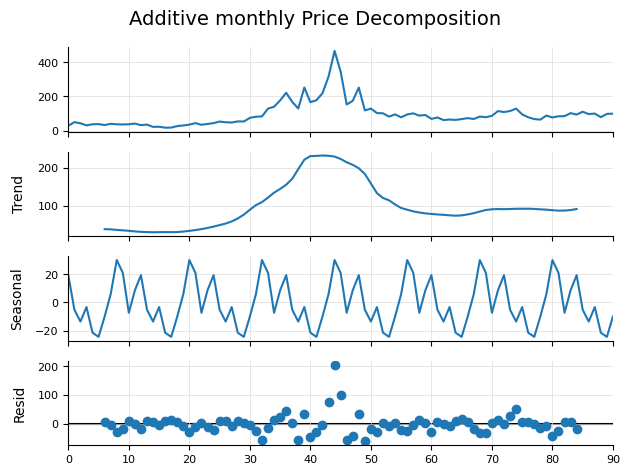

In [79]:
# decompose seasonality using seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_price_gen_monthly['price_de_lu_eur_mwh'], model='additive', period=12) # monthly data, so period is 12 months
fig = decomposition.plot()
fig.suptitle('Additive monthly Price Decomposition', fontsize=14)
fig.axes[0].set_title("") 
plt.show();

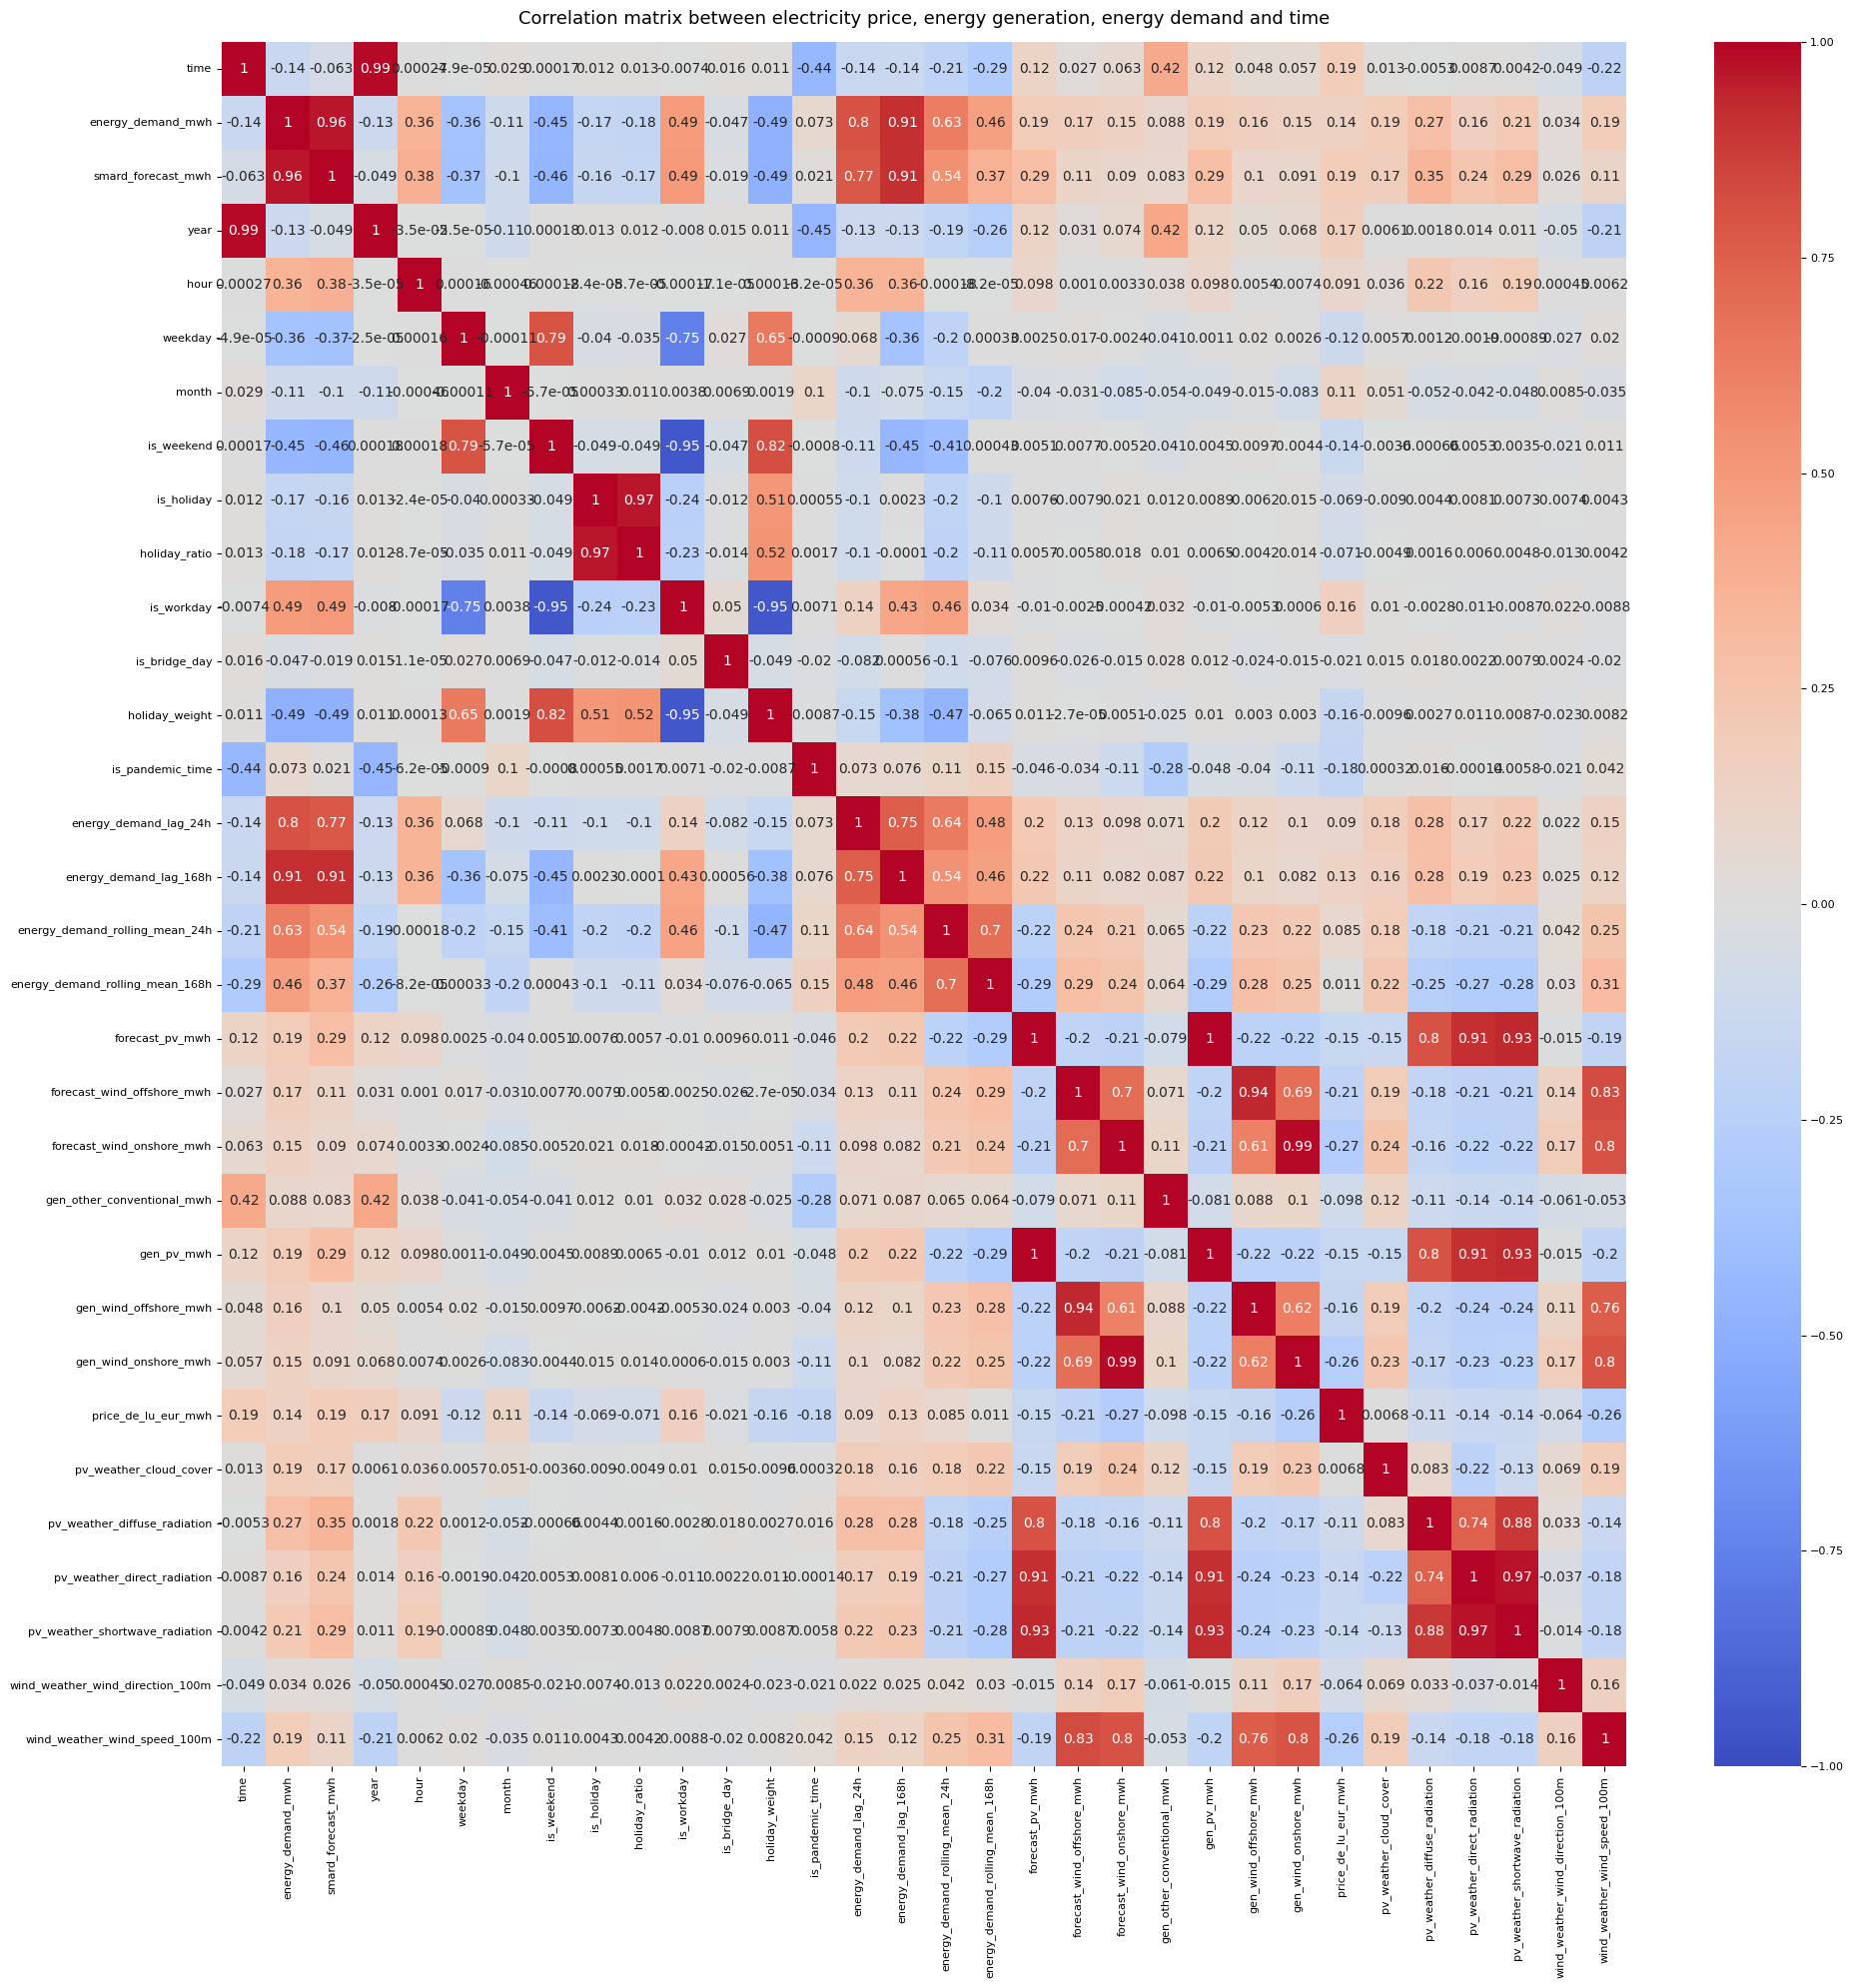

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(df_demand_price.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation matrix between electricity price, energy generation, energy demand and time')
plt.tight_layout()
plt.show()

### Distribution on different time features

* is_weekend, is_holiday, is_bridge_day distribution
* Weekday, week, month distribution

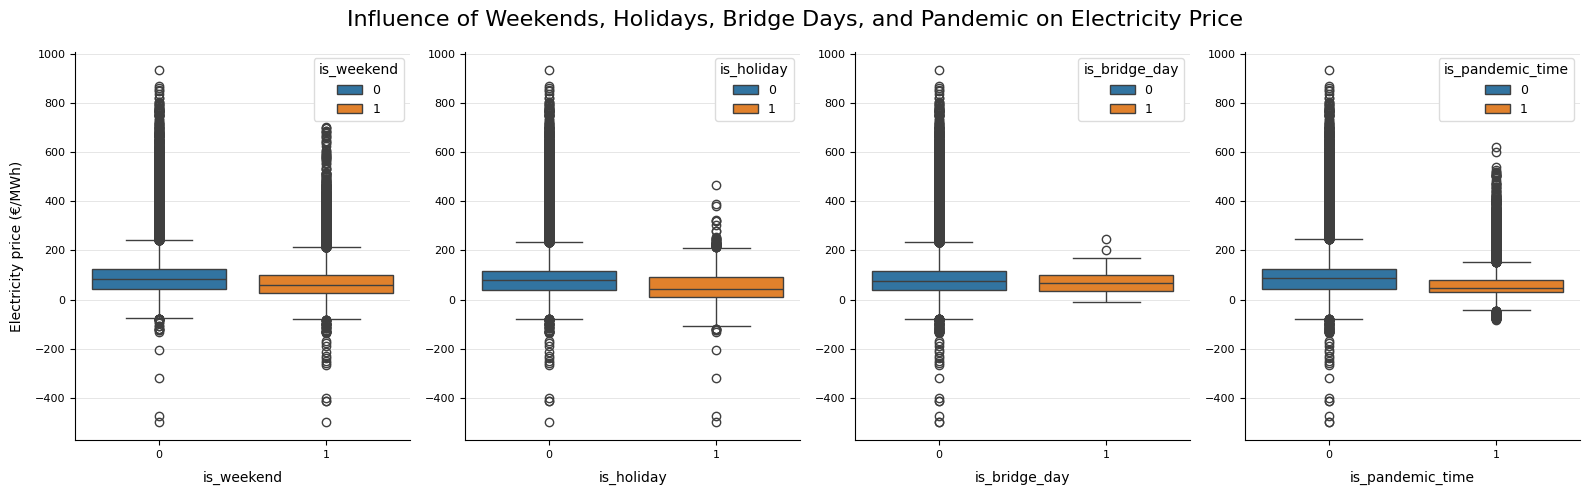

In [25]:
# plot weekend, holiday effects
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# boxplot for weekend, holiday effects
plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1)
sns.boxplot(x='is_weekend', y='price_de_lu_eur_mwh', hue='is_weekend', data=df_demand_price)
plt.ylabel('Electricity price (€/MWh)')
plt.subplot(1, 4, 2)
plt.ylabel('Electricity price (€/MWh)')
sns.boxplot(x='is_holiday', y='price_de_lu_eur_mwh', hue='is_holiday', data=df_demand_price)
plt.ylabel('')
plt.subplot(1, 4, 3)
sns.boxplot(x='is_bridge_day', y='price_de_lu_eur_mwh', hue='is_bridge_day', data=df_demand_price)
plt.ylabel('')
plt.subplot(1, 4, 4)
sns.boxplot(x='is_pandemic_time', y='price_de_lu_eur_mwh', hue='is_pandemic_time', data=df_demand_price)
plt.ylabel('')

plt.suptitle('Influence of Weekends, Holidays, Bridge Days, and Pandemic on Electricity Price', fontsize=16)

plt.tight_layout()
plt.show()



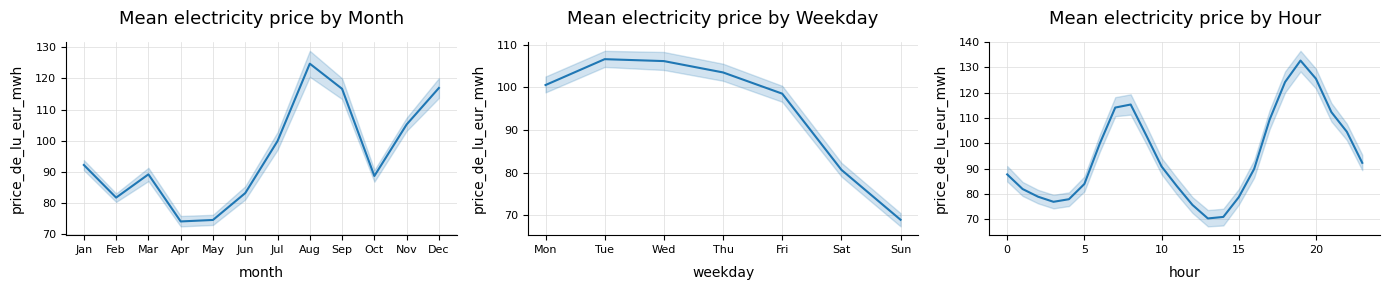

In [27]:
# plot mean energy demand by month, weekday, hour
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14, 3))
# rename x-axis labels for better readability
df_demand_price['month'] = df_demand_price['month'].map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})
df_demand_price['weekday'] = df_demand_price['weekday'].map({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})  
# sort the weekday order
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_demand_price['weekday'] = pd.Categorical(df_demand_price['weekday'], categories=weekday_order, ordered=True) 

plt.subplot(1, 3, 1)
sns.lineplot(x='month', y='price_de_lu_eur_mwh', data=df_demand_price)
plt.title('Mean electricity price by Month')    
plt.subplot(1, 3, 2)
sns.lineplot(x='weekday', y='price_de_lu_eur_mwh', data=df_demand_price)
plt.title('Mean electricity price by Weekday')
plt.subplot(1, 3, 3)
sns.lineplot(x='hour', y='price_de_lu_eur_mwh', data=df_demand_price)
plt.title('Mean electricity price by Hour')
plt.tight_layout()
plt.show()